In [1]:
import medmnist
from medmnist import INFO
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


In [2]:
# Load BreastMNIST dataset
data_flag = 'breastmnist'
download = True
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Define the transformations (resize to 128x128)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load training and test datasets
train_dataset = DataClass(split='train', transform=transform, download=download, size=128)
test_dataset = DataClass(split='test', transform=transform, download=download, size=128)


In [3]:
# Extract image data and labels 
X_train = train_dataset.imgs
y_train = train_dataset.labels
X_test = test_dataset.imgs
y_test = test_dataset.labels

# Normalize and reshape the images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


X_train = np.expand_dims(X_train, axis=-1)  
X_test = np.expand_dims(X_test, axis=-1)   

# Checking the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (546, 128, 128, 1)
X_test shape: (156, 128, 128, 1)


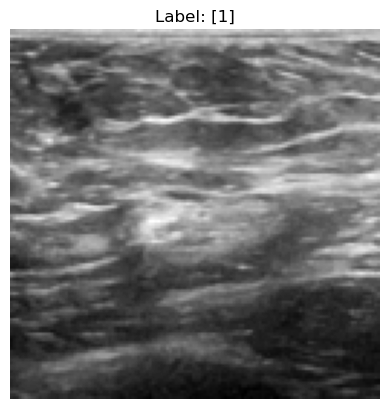

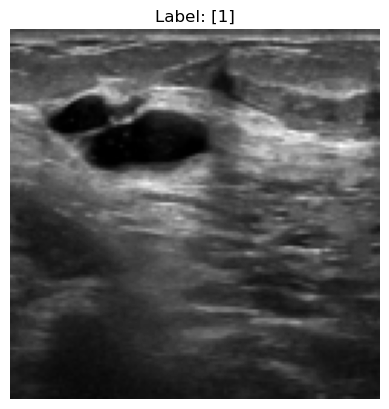

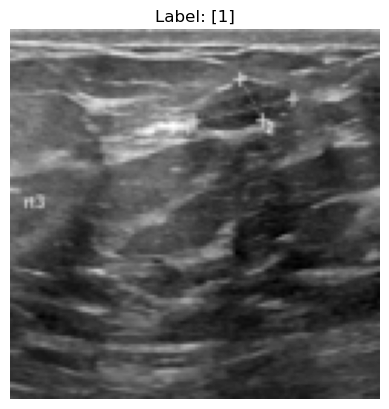

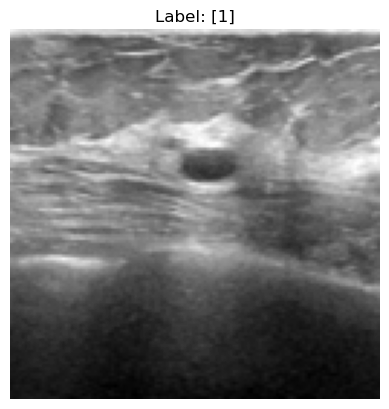

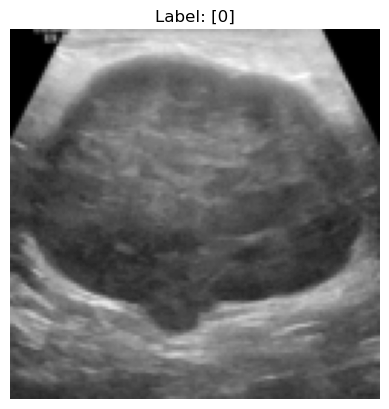

In [4]:
# Display first 5 training images
for i in range(5):
    plt.imshow(X_train[i].squeeze(), cmap='gray')  # .squeeze() to remove the channel dimension for display
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()


In [5]:
# Build the Keras CNN model
model = Sequential([
    Input(shape=(128, 128, 1)),  # Define the input shape (128x128 images with 1 channel)
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer=Adam(),
              loss=BinaryCrossentropy(),
              metrics=['accuracy'])

# Model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.6601 - loss: 0.6689 - val_accuracy: 0.7636 - val_loss: 0.5084
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.7600 - loss: 0.5437 - val_accuracy: 0.7636 - val_loss: 0.5705
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.7168 - loss: 0.5616 - val_accuracy: 0.7636 - val_loss: 0.4953
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.7226 - loss: 0.5625 - val_accuracy: 0.7636 - val_loss: 0.5179
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.7427 - loss: 0.5038 - val_accuracy: 0.7818 - val_loss: 0.5051
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.7333 - loss: 0.5153 - val_accuracy: 0.7636 - val_loss: 0.5012
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.7323 - loss: 0.5180 - val_accuracy: 0.8000 - val_loss: 0.5117
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.7755 - loss: 0.4766 - val_accuracy: 0.7818 - val_loss:

In [7]:
# Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7642 - loss: 0.4693
Test Accuracy: 0.7756


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


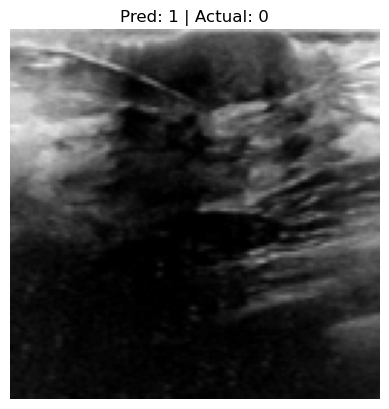

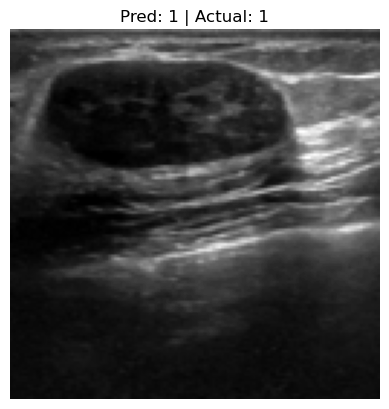

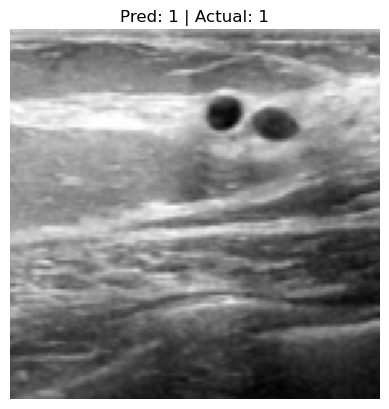

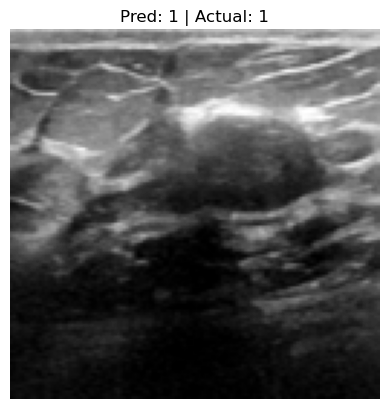

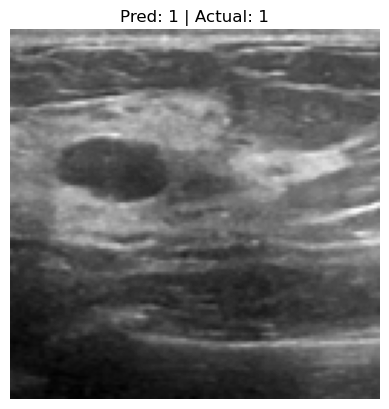

In [8]:
# Make predictions on the test data
predictions = (model.predict(X_test[:5]) > 0.5).astype("int32")

# Display the first 5 predictions
for i in range(5):
    plt.imshow(X_test[i].reshape(128,128), cmap='gray')
    plt.title(f"Pred: {predictions[i][0]} | Actual: {y_test[i][0]}")
    plt.axis('off')
    plt.show()
